# 7.3.3 创新、误差与区间覆盖

## 学习目标与先修知识

用独立重复检验创新和区间覆盖，区分误差与不确定性校准。

先修：7.3.2的创新与预测方差（variance），以及第5篇独立重复、标准误（standard error）和覆盖率。 [本篇学习次序](../README.md)。

## 具体问题

两种滤波器画出的曲线都很平滑，是否意味着给出的95%区间可靠？我们用完全相同的人工轨迹（trajectory），比较正确测量方差和过分自信的方差设定。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]

## 初步实验

In [2]:
errors=np.array([0.,1.,2.,4.]);inside=np.abs(errors)<=2
print('RMSE=',np.sqrt(np.mean(errors**2)),'区间覆盖率=',inside.mean())

RMSE= 2.29128784747792 区间覆盖率= 0.75


## 模型假设

独立重复（independent replication）以整条轨迹为单位，终点为固定评价时刻。模型（model）内的初态、过程噪声（process noise）和传感器噪声均由已声明分布（distribution）抽取；估计器只接收观测（observation）。随机种子（random seed）20260919，240条、每条30步，两方法共享每条轨迹；真值仅用于事后核验。

## 数学解释与推导

标准化创新为 $z_t=r_t/\sqrt{S_t}$。在线性高斯且模型、初始化正确时，创新为零均值、方差 $S_t$；跨时刻不相关，因此z的理论均值0、方差1。

固定终点的边际区间 $[m-1.96\sqrt P,m+1.96\sqrt P]$ 在模型下约覆盖95%。对M条独立轨迹，覆盖指示 $I_j\in\{0,1\}$，
$$\hat c=M^{-1}\sum_jI_j,\quad \widehat{\mathrm{SE}}(\hat c)=\sqrt{\hat c(1-\hat c)/M}.$$
均方根误差（root mean squared error，RMSE）衡量点估计误差，覆盖率（coverage）衡量区间校准（calibration）；二者不可互代。同一条轨迹的多个覆盖指示通常相关，不能当作M个独立实验缩小标准误。0或1的代入标准误为0也不意味着无限确定。

## 核心实现

下面按推导写出计算步骤；函数的输入（input）只包含模型与当时可用的信息。

In [3]:
def kalman_filter(transition, sensor, process_covariance, measurement_variance,
                  initial_mean, initial_covariance, observations):
    F, H, Q = map(lambda x: np.array(x, float), (transition, sensor, process_covariance))
    mean, covariance = np.array(initial_mean, float), np.array(initial_covariance, float)
    result = dict(predicted_means=[], predicted_covariances=[], means=[], covariances=[], innovations=[], innovation_variances=[])
    for t, observed in enumerate(observations):
        if t:
            mean, covariance = F @ mean, F @ covariance @ F.T + Q
        result['predicted_means'].append(mean.tolist())
        result['predicted_covariances'].append(covariance.tolist())
        innovation_variance = float(H @ covariance @ H + measurement_variance)
        innovation = None if observed is None else float(observed - H @ mean)
        if observed is not None:
            gain = covariance @ H / innovation_variance
            mean = mean + gain * innovation
            # Joseph形式保留测量噪声项；数学上等于P-KSKᵀ。
            residual_map = np.eye(len(mean)) - np.outer(gain, H)
            covariance = residual_map @ covariance @ residual_map.T + np.outer(gain, gain) * measurement_variance
            covariance = (covariance + covariance.T) / 2
        result['means'].append(mean.tolist())
        result['covariances'].append(covariance.tolist())
        result['innovations'].append(innovation)
        result['innovation_variances'].append(innovation_variance)
    return result

## 对照实验

| 模型 | 终点RMSE/U | 覆盖比例 | 覆盖标准误 | 创新均值 | 创新方差 |
| --- | --- | --- | --- | --- | --- |
| 正确R | 0.194086 | 0.941667 | 0.0151287 | 0.0235994 | 1.34682 |
| R缩小十倍 | 0.298571 | 0.454167 | 0.032139 | 0.0941927 | 6.84178 |

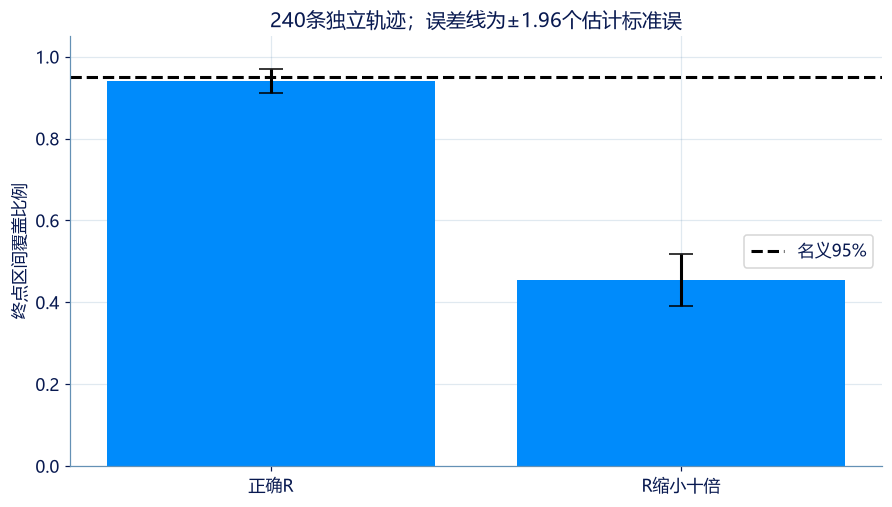

In [4]:
rng=np.random.default_rng(20260919);M=240;T=30;F=np.array([[.85,.1],[.1,.8]]);H=np.array([1.,0.]);Q=.02*np.eye(2);R=.16;m0=np.array([2.,0.]);P0=np.eye(2)
errors=[[],[]];covers=[[],[]];innovations=[[],[]]
for repeat in range(M):
    truth=[rng.multivariate_normal(m0,P0)]
    for _ in range(T-1):truth.append(F@truth[-1]+rng.multivariate_normal(np.zeros(2),Q))
    truth=np.array(truth);observed=truth@H+rng.normal(0,math.sqrt(R),T)
    for i,assumed_R in enumerate([R,R/10]):
        result=kalman_filter(F,H,Q,assumed_R,m0,P0,observed)
        error=truth[-1,0]-result['means'][-1][0];sd=math.sqrt(result['covariances'][-1][0][0])
        errors[i].append(error);covers[i].append(abs(error)<=1.96*sd)
        innovations[i].append(result['innovations'][-1]/math.sqrt(result['innovation_variances'][-1]))
rows=[]
for label,err,inside,z in zip(['正确R','R缩小十倍'],errors,covers,innovations):
    coverage=np.mean(inside);se=np.sqrt(coverage*(1-coverage)/M)
    rows.append([label,float(np.sqrt(np.mean(np.array(err)**2))),float(coverage),float(se),float(np.mean(z)),float(np.var(z,ddof=1))])
display(Markdown(show_table(['模型','终点RMSE/U','覆盖比例','覆盖标准误','创新均值','创新方差'],rows)))
fig,ax=plt.subplots(figsize=(8,4.5));ax.bar(['正确R','R缩小十倍'],[row[2] for row in rows],yerr=[1.96*row[3] for row in rows],capsize=8);ax.axhline(.95,color='black',ls='--',label='名义95%');ax.set(ylim=(0,1.05),ylabel='终点区间覆盖比例',title='240条独立轨迹；误差线为±1.96个估计标准误');ax.legend();plt.show()

### 独立核验与边界

In [5]:
assert len(errors[0])==M and len(errors[1])==M
assert all(np.isfinite(row[1:]).all() for row in rows)
print('预算：',M*T*2,'次小矩阵滤波步。只在固定终点评价，避免混用时间相关样本。')

预算： 14400 次小矩阵滤波步。只在固定终点评价，避免混用时间相关样本。


## 结果解释

表中误差、覆盖和创新统计来自实际重复结果。过小R让算法过度相信读数，并可能给出过窄区间；一次实验仍有抽样波动，不能要求覆盖率精确等于0.95。若创新有持续偏差，还应检查动力学或传感器偏置，而不只调整R。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：误差与覆盖率分开算

固定时刻进行了独立重复实验。给出核验状态（state）、估计均值和标准差（standard deviation），返回均方根误差（root mean squared error，RMSE）、区间覆盖率及覆盖率的二项标准误（standard error）估计。

**函数与代码模板**

```python
def solve(
    truth: list[float],
    means: list[float],
    standard_deviations: list[float],
    z: float,
) -> tuple[float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `truth` | `list[float]` | 每次独立实验的核验状态。 | U |
| `means` | `list[float]` | 对应后验（posterior）均值。 | U |
| `standard_deviations` | `list[float]` | 对应后验标准差，非方差（variance）。 | U |
| `z` | `float` | 区间半宽的标准差倍数。 | 无量纲 |

**返回值**

按以下顺序返回元组：(rmse, coverage, standard_error)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rmse` | `float` | sqrt(mean((truth−means)²))。 | U |
| `coverage` | `float` | 落入闭区间mean±z*std的比例。 | 比例 |
| `standard_error` | `float` | sqrt(coverage*(1−coverage)/n)，仅为代入估计。 | 比例 |

**计算规则**

使用闭区间，即边界计覆盖。标准误以独立重复为单位，不把同一序列时刻当独立样本；覆盖率为0或1时标准误估计0不表示真实不确定性为0。

**约束与边界**

- 三个列表等长，1—1000项；标准差≥0，z>0；所有数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| truth | 每次独立实验的核验状态。 | [0.0, 1.0, 2.0, 4.0] | U |
| means | 对应后验（posterior）均值。 | [0.0, 0.0, 0.0, 0.0] | U |
| standard_deviations | 对应后验标准差，非方差（variance）。 | [1.0, 1.0, 1.0, 1.0] | U |
| z | 区间半宽的标准差倍数。 | 2 | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
truth = [0.0, 1.0, 2.0, 4.0]
means = [0.0, 0.0, 0.0, 0.0]
standard_deviations = [1.0, 1.0, 1.0, 1.0]
z = 2.0

result = solve(truth, means, standard_deviations, z)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rmse | sqrt(mean((truth−means)²))。 | ≈ 2.291288 | U |
| coverage | 落入闭区间mean±z*std的比例。 | 0.75 | 比例 |
| standard_error | sqrt(coverage*(1−coverage)/n)，仅为代入估计。 | ≈ 0.2165064 | 比例 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (2.29128784747792,
                   0.75,
                   0.21650635094610965)
```

**样例解释**

前3次误差不超过2U，覆盖率0.75；RMSE=sqrt(21/4)，代入标准误约0.2165。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：误差与覆盖率分开算](http://127.0.0.1:8000/chapters/07-03-%E5%8D%A1%E5%B0%94%E6%9B%BC%E6%BB%A4%E6%B3%A2/practice/?question=p07-coverage)

### 第 2 题 · 单项选择题：谁是独立重复

同一条轨迹（trajectory）有100个时刻，另有200条独立轨迹。要估计终点95%区间的覆盖率不确定性，哪项合适？

- **A.** 把全部20000个时刻都当独立终点。
- **B.** 每条独立轨迹取终点覆盖指示，共200项。
- **C.** 只保留覆盖的轨迹。
- **D.** 使用平滑后的终点之前结果替代滤波却不改任务。

[作答：谁是独立重复](http://127.0.0.1:8000/chapters/07-03-%E5%8D%A1%E5%B0%94%E6%9B%BC%E6%BB%A4%E6%B3%A2/practice/?question=p07-coverage-unit)

### 第 3 题 · 多项选择题：创新应该接近什么

模型（model）和噪声设定正确的线性高斯滤波，在正确初始化下，归一化创新的理论特征包括哪些？

- **A.** 均值0。
- **B.** 方差（variance）1。
- **C.** 有限样本中每个数必须等于0。
- **D.** 不同时刻不相关。

[作答：创新应该接近什么](http://127.0.0.1:8000/chapters/07-03-%E5%8D%A1%E5%B0%94%E6%9B%BC%E6%BB%A4%E6%B3%A2/practice/?question=p07-innovation-whiteness)

### 第 4 题 · 单项选择题：误差小就校准好吗

方法甲RMSE=0.5、95%区间覆盖率70%；乙RMSE=0.6、覆盖率94%。均来自同样独立场景。哪项有依据？

- **A.** 甲的区间一定更可靠。
- **B.** 甲点估计误差较小，但区间在本实验中偏窄或模型（model）有失配。
- **C.** 乙必适用于所有生理系统。
- **D.** 只要把区间改宽，模型结构（model structure）就被验证了。

[作答：误差小就校准好吗](http://127.0.0.1:8000/chapters/07-03-%E5%8D%A1%E5%B0%94%E6%9B%BC%E6%BB%A4%E6%B3%A2/practice/?question=p07-calibration-failure)

### 延伸阅读

R26，第6章滤波及模型评估的条件；统计标准误沿用第5篇。 [Särkkä 与 Svensson，《Bayesian Filtering and Smoothing》第二版，2023](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf)。本节公式、实现和核验可独立阅读；参考资料用于进一步学习。

[概念探索与交互](http://127.0.0.1:8000/chapters/07-03-卡尔曼滤波/explore/) · [本篇目录](../README.md)